In [ ]:
# ============================================================
# 1. Cargar librerías
# ============================================================

# Librerías para manejo de datos
import pandas as pd
import numpy as np

# Librerías para gráficos
import matplotlib.pyplot as plt

# Librerías para Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# ============================================================
# 2. Leer archivo desde URL
# ============================================================

# URL del dataset Auto MPG
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

# Nombres de columnas del dataset
columnas = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

# Cargamos el dataset desde la URL
df = pd.read_csv(
    url,
    sep=r"\s+",
    names=columnas,
    na_values="?",
    quotechar='"'
)

# Mostramos las primeras filas
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [ ]:
# ============================================================
# 3. EDA mínimo
# ============================================================

# Revisamos el tamaño del dataset
df.shape


(398, 9)

In [ ]:
# Revisamos información general del dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [ ]:
# Revisamos valores nulos
df.isnull().sum()


,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


In [ ]:
# Revisamos estadísticas básicas
df.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


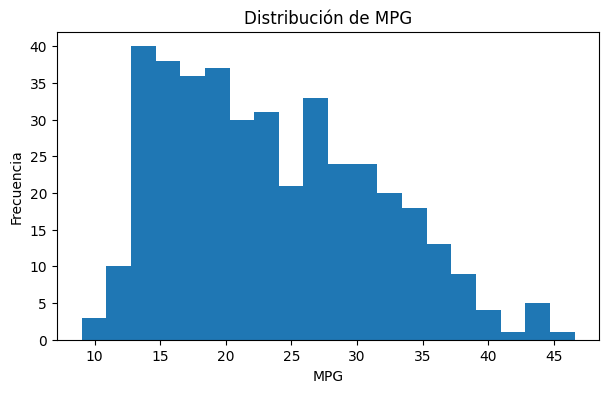

In [ ]:
# Visualizamos la variable objetivo

plt.figure(figsize=(7, 4))
plt.hist(df["mpg"], bins=20)
plt.title("Distribución de MPG")
plt.xlabel("MPG")
plt.ylabel("Frecuencia")
plt.show()


In [ ]:
# ============================================================
# 4. Definir variable objetivo
# ============================================================

# La variable objetivo es mpg porque queremos predecir consumo de combustible
variable_objetivo = "mpg"

# Revisamos la variable objetivo
df[variable_objetivo].head()


,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


In [ ]:
# ============================================================
# 5. Generar X e y
# ============================================================

# X contiene las variables predictoras
X = df.drop(columns=[variable_objetivo])

# y contiene la variable objetivo
y = df[variable_objetivo]

# Revisamos X
X.head()


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [ ]:
# Revisamos y
y.head()


,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


In [ ]:
# ============================================================
# 6. Eliminar columnas no necesarias
# ============================================================

# Eliminamos car_name porque es un nombre de auto y no ayuda en este ejemplo simple
X = X.drop(columns=["car_name"])

# Revisamos las columnas restantes
X.head()


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,8,307.0,130.0,3504.0,12.0,70,1
1,8,350.0,165.0,3693.0,11.5,70,1
2,8,318.0,150.0,3436.0,11.0,70,1
3,8,304.0,150.0,3433.0,12.0,70,1
4,8,302.0,140.0,3449.0,10.5,70,1


In [ ]:
# ============================================================
# 7. Imputación de datos
# ============================================================

# Revisamos valores nulos en X
X.isnull().sum()


,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0


In [ ]:
# Imputamos los valores nulos de horsepower con la mediana
X["horsepower"] = X["horsepower"].fillna(X["horsepower"].median())

# Confirmamos que ya no hay nulos
X.isnull().sum()


,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0


In [ ]:
# ============================================================
# 8. Variables Dummy si hace falta
# ============================================================

# La variable origin es numérica, pero representa una categoría
# La convertimos a texto para crear variables dummy
X["origin"] = X["origin"].astype(str)

# Creamos variables dummy para origin
X = pd.get_dummies(X, columns=["origin"], drop_first=True)

# Revisamos el resultado
X.head()


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_2,origin_3
0,8,307.0,130.0,3504.0,12.0,70,False,False
1,8,350.0,165.0,3693.0,11.5,70,False,False
2,8,318.0,150.0,3436.0,11.0,70,False,False
3,8,304.0,150.0,3433.0,12.0,70,False,False
4,8,302.0,140.0,3449.0,10.5,70,False,False


In [ ]:
# ============================================================
# 9. Dividir en Training y Testing
# ============================================================

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Revisamos tamaños
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (278, 8)
X_test: (120, 8)
y_train: (278,)
y_test: (120,)


In [ ]:
# ============================================================
# 10. Escalar datos si es necesario
# ============================================================

# Para un árbol CART no es necesario escalar los datos.
# Los árboles hacen cortes sobre las variables y no dependen de distancias.

X_train.head()


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_2,origin_3
157,8,350.0,145.0,4440.0,14.0,75,False,False
109,4,140.0,72.0,2401.0,19.5,73,False,False
17,6,200.0,85.0,2587.0,16.0,70,False,False
253,6,200.0,95.0,3155.0,18.2,78,False,False
24,6,199.0,90.0,2648.0,15.0,70,False,False


In [ ]:
# ============================================================
# 11. Crear el modelo CART de regresión
# ============================================================

# Creamos el modelo de árbol de decisión para regresión
modelo_cart = DecisionTreeRegressor(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Entrenamos el modelo
modelo_cart.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

In [ ]:
# ============================================================
# 12. Hacer predicciones
# ============================================================

# Generamos predicciones con el set de prueba
y_pred = modelo_cart.predict(X_test)

# Mostramos las primeras predicciones
y_pred[:10]


array([30.36842105, 27.08636364, 17.82758621, 14.56896552, 14.56896552,
       24.60714286, 27.08636364, 12.89583333, 20.23043478, 17.82758621])

In [ ]:
# ============================================================
# 13. Métricas del modelo de regresión
# ============================================================

# Calculamos MAE, RMSE y R2
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))


MAE: 2.24
RMSE: 3.03
R2: 0.84


In [ ]:
# ============================================================
# 14. Comparar valores reales vs predichos
# ============================================================

# Creamos una tabla de comparación
resultados = pd.DataFrame({
    "Real": y_test.values,
    "Predicción": y_pred
})

# Calculamos el error
resultados["Error"] = resultados["Real"] - resultados["Predicción"]

# Mostramos los primeros resultados
resultados.head(15)


,Real,Predicción,Error
0,33.0,30.368421,2.631579
1,28.0,27.086364,0.913636
2,19.0,17.827586,1.172414
3,13.0,14.568966,-1.568966
4,14.0,14.568966,-0.568966
5,27.0,24.607143,2.392857
6,24.0,27.086364,-3.086364
7,13.0,12.895833,0.104167
8,17.0,20.230435,-3.230435
9,21.0,17.827586,3.172414


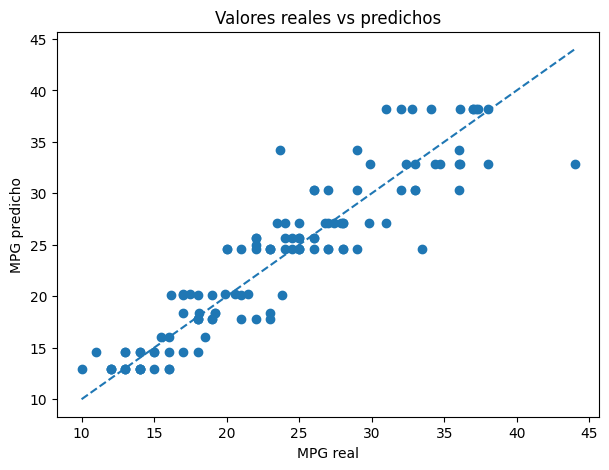

In [ ]:
# ============================================================
# 15. Visualizar valores reales vs predichos
# ============================================================

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Valores reales vs predichos")
plt.xlabel("MPG real")
plt.ylabel("MPG predicho")
plt.show()


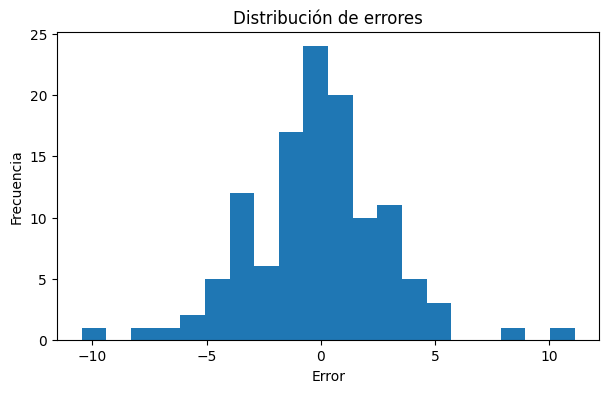

In [ ]:
# ============================================================
# 16. Visualizar errores del modelo
# ============================================================

plt.figure(figsize=(7, 4))
plt.hist(resultados["Error"], bins=20)
plt.title("Distribución de errores")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()


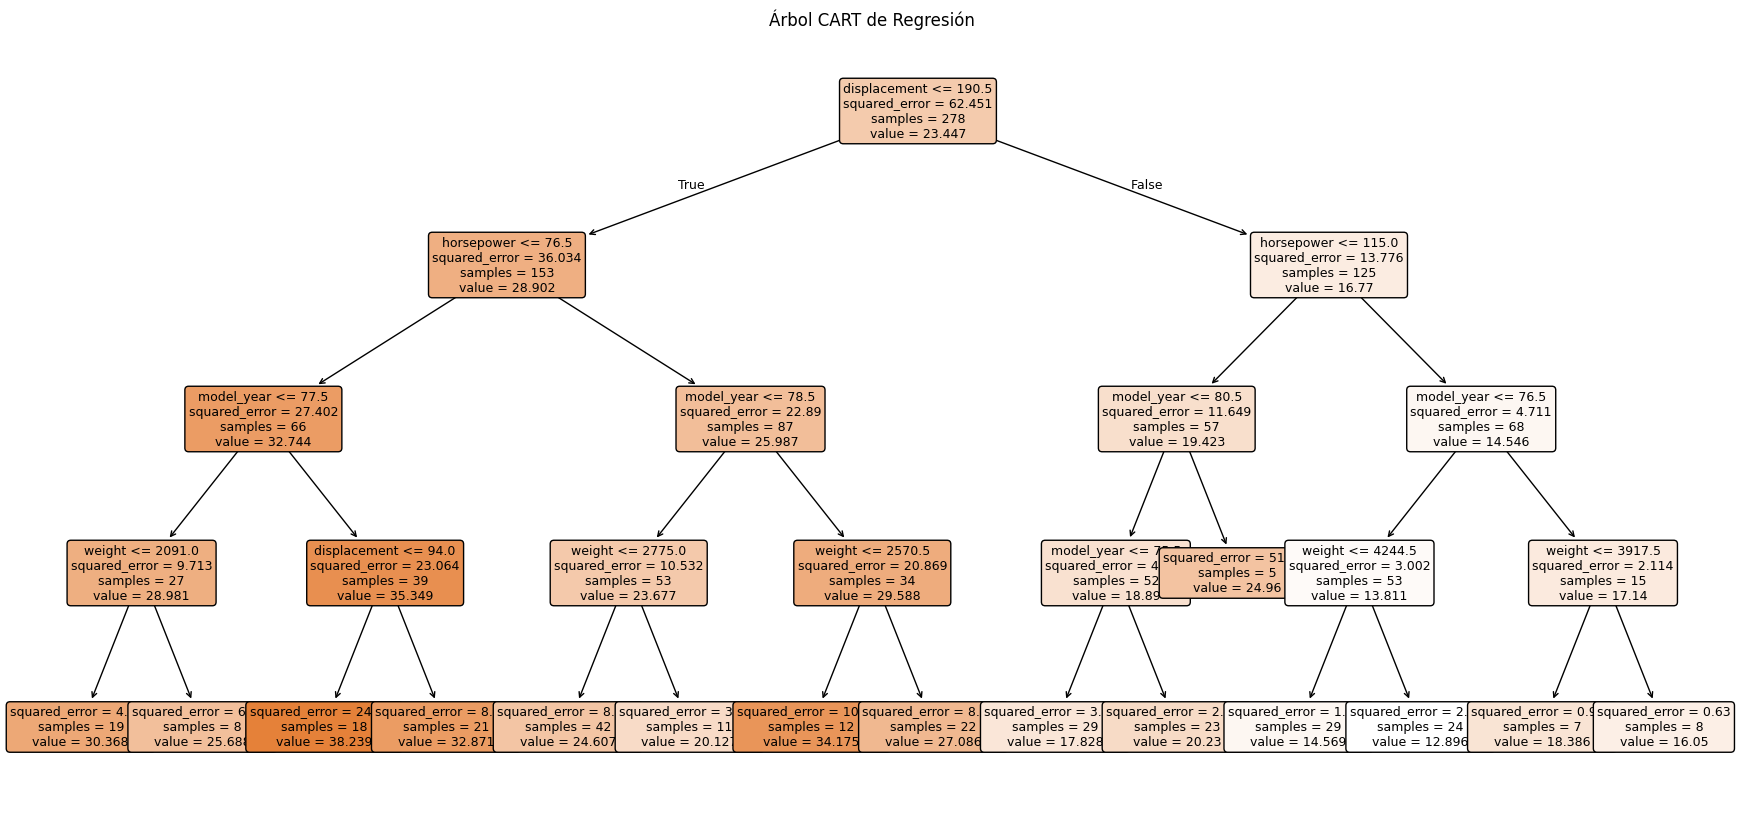

In [ ]:
# ============================================================
# 17. Visualizar el árbol CART
# ============================================================

plt.figure(figsize=(22, 10))

plot_tree(
    modelo_cart,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Árbol CART de Regresión")
plt.show()


In [ ]:
# ============================================================
# 18. Importancia de variables
# ============================================================

# Creamos una tabla con la importancia de cada variable
importancia = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_cart.feature_importances_
})

# Ordenamos de mayor a menor
importancia = importancia.sort_values(by="Importancia", ascending=False)

importancia


,Variable,Importancia
1,displacement,0.678143
2,horsepower,0.159728
5,model_year,0.113538
3,weight,0.048592
0,cylinders,0.000000
4,acceleration,0.000000
6,origin_2,0.000000
7,origin_3,0.000000


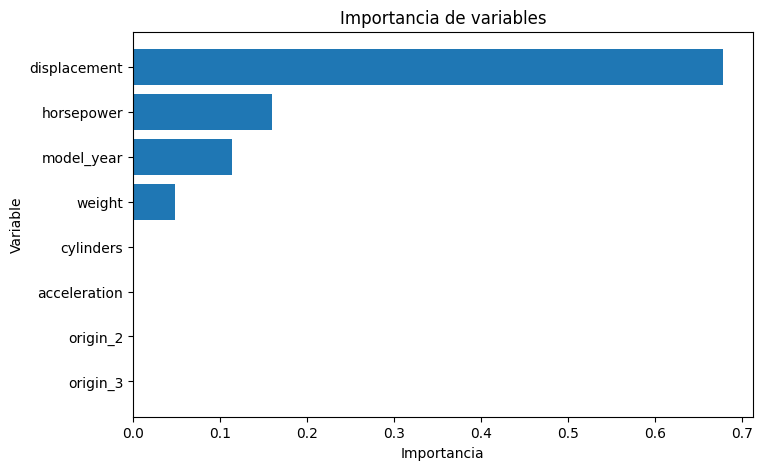

In [ ]:
# Visualizamos la importancia de variables

plt.figure(figsize=(8, 5))
plt.barh(importancia["Variable"], importancia["Importancia"])
plt.title("Importancia de variables")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# ============================================================
# 19. Interfaz simple de predicción
# ============================================================

# Ingresamos los datos de un nuevo auto
cylinders = 4
displacement = 140
horsepower = 90
weight = 2500
acceleration = 15
model_year = 80
origin = "1"

# Creamos un dataframe con el nuevo auto
nuevo_auto = pd.DataFrame({
    "cylinders": [cylinders],
    "displacement": [displacement],
    "horsepower": [horsepower],
    "weight": [weight],
    "acceleration": [acceleration],
    "model_year": [model_year],
    "origin": [origin]
})

# Creamos variables dummy para el nuevo auto
nuevo_auto = pd.get_dummies(nuevo_auto, columns=["origin"], drop_first=True)

# Alineamos las columnas con las usadas en el modelo
nuevo_auto = nuevo_auto.reindex(columns=X.columns, fill_value=0)

# Generamos la predicción
prediccion_mpg = modelo_cart.predict(nuevo_auto)

print("El MPG estimado para el nuevo auto es:", round(prediccion_mpg[0], 2))


In [ ]:
# ============================================================
# 20. Interfaz con input del usuario
# ============================================================

# Esta parte permite ingresar datos manualmente

cylinders = int(input("Ingrese el número de cilindros: "))
displacement = float(input("Ingrese el displacement: "))
horsepower = float(input("Ingrese el horsepower: "))
weight = float(input("Ingrese el peso del auto: "))
acceleration = float(input("Ingrese la aceleración: "))
model_year = int(input("Ingrese el año del modelo, por ejemplo 80: "))
origin = input("Ingrese el origen del auto, 1, 2 o 3: ")

nuevo_auto = pd.DataFrame({
    "cylinders": [cylinders],
    "displacement": [displacement],
    "horsepower": [horsepower],
    "weight": [weight],
    "acceleration": [acceleration],
    "model_year": [model_year],
    "origin": [origin]
})

nuevo_auto = pd.get_dummies(nuevo_auto, columns=["origin"], drop_first=True)
nuevo_auto = nuevo_auto.reindex(columns=X.columns, fill_value=0)

prediccion_mpg = modelo_cart.predict(nuevo_auto)

print("El MPG estimado para el nuevo auto es:", round(prediccion_mpg[0], 2))


In [ ]:
# ============================================================
# 21. Conclusión simple
# ============================================================

print("El modelo CART de regresión fue entrenado para predecir MPG.")
print("La variable objetivo fue mpg.")
print("No fue necesario escalar los datos.")
print("Las métricas usadas fueron MAE, RMSE y R2.")
print("También se visualizó el árbol y la importancia de variables.")
